# Accelerometer & Magnetometer



In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
data = pd.read_csv('data/imu_xyz.csv')

euler_gt = data[['euler_x', 'euler_y', 'euler_z']].values
acc = data[['accelerometer_x', 'accelerometer_y', 'accelerometer_z']].values
mag = data[['magnetometer_x', 'magnetometer_y', 'magnetometer_z']].values

In [9]:
acc_si = acc / 16384.0 * 9.81
print(acc_si)

[[ 0.          0.         -9.81      ]
 [ 0.          0.         -9.81      ]
 [ 0.          0.         -9.81      ]
 ...
 [-2.63469222 -1.25257168 -9.36619224]
 [-2.64670474 -1.20779356 -9.36868608]
 [-2.65305804 -1.18545566 -9.36974267]]


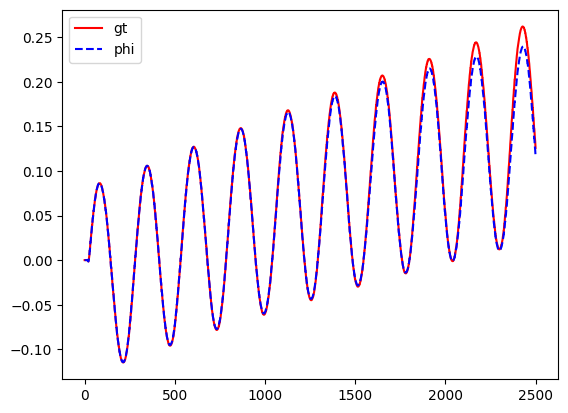

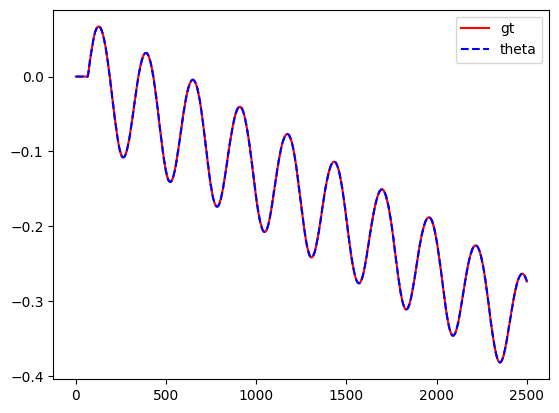

In [10]:
N = len(acc_si)

theta = np.zeros(N)
phi = np.zeros(N)
g = 9.81
for i in range(N):
    x, y, z = acc_si[i]
    theta[i] = np.arcsin(x / g) 
    phi[i] = -np.arcsin(y / g*np.cos(theta[i]))
    # theta[i] = np.arctan2(x, np.sqrt(y**2 + z**2))
    # phi[i] = np.arctan2(-y, -z)


plt.figure()
plt.plot(euler_gt[:, 0] * np.pi/180, 'r', label='gt')
plt.plot(phi, 'b--', label='phi')
plt.legend()

plt.figure()
plt.plot(euler_gt[:, 1]* np.pi/180, label='gt', color='r')
plt.plot(theta, 'b--', label='theta' )
plt.legend()



In [11]:
mag_si = mag / 45
print(mag_si)

[[ 1.          0.          0.        ]
 [ 1.          0.          0.        ]
 [ 1.          0.          0.        ]
 ...
 [ 0.92276933 -0.31845608 -0.21698511]
 [ 0.92179981 -0.31974977 -0.21919193]
 [ 0.92132289 -0.32033077 -0.22034596]]


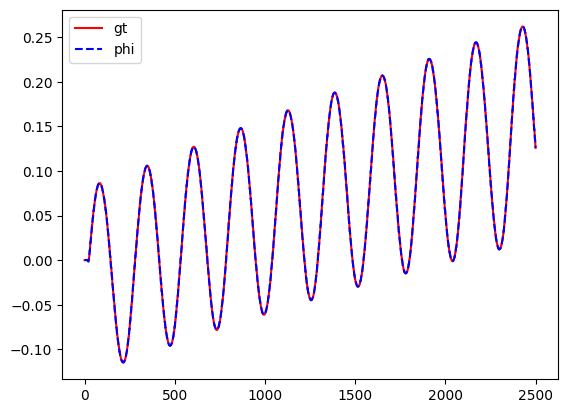

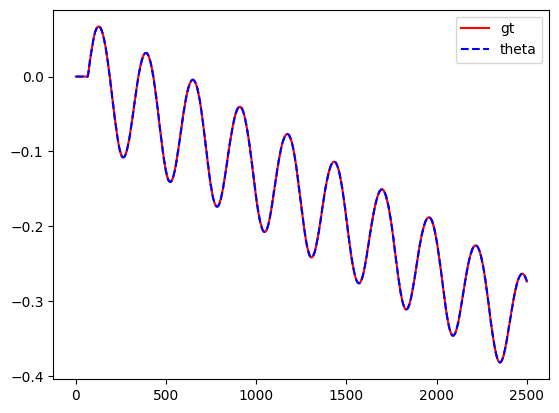

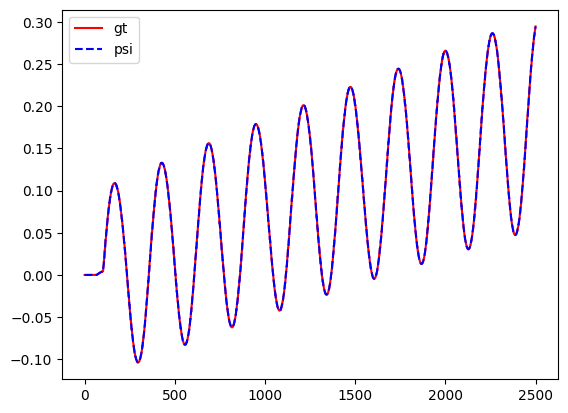

In [12]:
N = len(acc_si)

theta = np.zeros(N)
phi = np.zeros(N)
psi = np.zeros(N)

g = 9.81
for i in range(N):
    x, y, z = acc_si[i]
    mx, my, mz = mag_si[i]/np.linalg.norm(mag_si[i])
    theta[i] = np.arcsin(x / g) 
    phi[i] = -np.arcsin(y / (g*np.cos(theta[i])))
    # psi[i] = np.arctan2(mz-np.cos(phi[i])*np.sin(theta[i]) , np.sin(phi[i]) )
    sinphi = np.sin(phi[i])
    sinthe = np.sin(theta[i])
    cosphi = np.cos(phi[i])
    costhe = np.cos(theta[i])
    cospsi= mx / costhe
    sinpsi= (-my + sinphi*sinthe*cospsi)/cosphi
    psi[i] = np.arctan2(sinpsi, cospsi)


plt.figure()
plt.plot(euler_gt[:, 0] * np.pi/180, 'r', label='gt')
plt.plot(phi, 'b--', label='phi')
plt.legend()

plt.figure()
plt.plot(euler_gt[:, 1]* np.pi/180, label='gt', color='r')
plt.plot(theta, 'b--', label='theta' )
plt.legend()

plt.figure()
plt.plot(euler_gt[:, 2]* np.pi/180, label='gt', color='r')
plt.plot(psi, 'b--', label='psi' )
plt.legend()





